<a href="https://colab.research.google.com/github/sskyoz/machine_learning/blob/main/projet_Deep_Learning_Essadik_partie1MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de fin de module — Deep Learning
## Partie I — Perceptron Multicouche (MLP) & ingénierie PyTorch

**Réalisé par :** Essadik &nbsp;·&nbsp; **Encadré par :** Mme HIDILA Zineb &nbsp;·&nbsp; **EMSI Casablanca — 2025/2026**

---

### Thème
Classification supervisée sur **données tabulaires réelles** avec un perceptron multicouche.

### Dataset retenu — *Breast Cancer Wisconsin (Diagnostic)*
- **569 échantillons**, **30 variables numériques** (caractéristiques de noyaux cellulaires extraites d'images de biopsies).
- **Tâche binaire** : `malin` (0) vs `bénin` (1).
- Classes **légèrement déséquilibrées** (~37 % malins / 63 % bénins) → l'*accuracy* seule ne suffit pas, on suivra aussi precision/recall/F1.

### Plan de la partie
1. Cadre théorique (`nn.Module`, paramètres, gradient, `state_dict`, *device*, forward/backprop).
2. Préparation rigoureuse des données (split stratifié, standardisation sans *data leakage*).
3. Deux implémentations du MLP : `nn.Sequential` **et** classe personnalisée.
4. Inspection des paramètres (`named_parameters()`, `state_dict()`).
5. Comparaison **expérimentale** de 3 stratégies d'initialisation (gaussienne, constante, Xavier).
6. Entraînement, sauvegarde **et rechargement** du meilleur modèle, gestion CPU/GPU.
7. Évaluation complète (accuracy, precision, recall, F1, matrice de confusion, ROC-AUC) + baseline + interprétabilité SHAP.
8. Analyse critique & question de synthèse.


## 1. Cadre théorique

### 1.1 Le neurone et la propagation avant (*forward*)
Un MLP enchaîne des **couches entièrement connectées**. Une couche calcule, pour une entrée $x \in \mathbb{R}^{d}$ :
$$ z = W^{\top}x + b, \qquad a = f(z) $$
où $W$ est la matrice de poids, $b$ le biais et $f$ une non-linéarité (ici **ReLU**, $f(z)=\max(0,z)$). L'empilement de couches non linéaires confère au réseau sa capacité d'**approximation universelle**.

### 1.2 `nn.Module`, paramètres et `state_dict`
- **`nn.Module`** est la classe de base de tout modèle PyTorch. On y déclare les sous-couches dans `__init__` et le flux de calcul dans `forward`.
- Les **paramètres** ($W$, $b$, paramètres $\gamma,\beta$ de BatchNorm) sont des `nn.Parameter` avec `requires_grad=True` : ils sont *appris* par descente de gradient.
- **`named_parameters()`** liste uniquement les tenseurs **apprenables** ; **`state_dict()`** liste *tout* l'état persistant, y compris les *buffers* non appris (ex. `running_mean`/`running_var` de BatchNorm). C'est `state_dict()` que l'on **sauvegarde**.

### 1.3 Gradient et rétropropagation (*backprop*)
PyTorch construit dynamiquement un **graphe de calcul**. Lors de `loss.backward()`, la règle de dérivation en chaîne propage le gradient de la perte $\mathcal{L}$ vers chaque paramètre :
$$ \frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{\partial \mathcal{L}}{\partial a^{(l)}}\cdot\frac{\partial a^{(l)}}{\partial z^{(l)}}\cdot\frac{\partial z^{(l)}}{\partial W^{(l)}} $$
L'optimiseur (Adam) applique ensuite `optimizer.step()`. **`optimizer.zero_grad()`** est indispensable en début d'itération car PyTorch *accumule* les gradients.

### 1.4 *Device* (CPU/GPU)
Le modèle **et** les données doivent résider sur le même *device*. On déplace les deux via `.to(device)`. Un désalignement (modèle GPU, données CPU) lève une erreur ; on vérifiera explicitement cette cohérence (§6).

### 1.5 Fonction de perte
Problème binaire → **`BCEWithLogitsLoss`**, qui combine *sigmoïde + BCE* de façon numériquement stable. **La sortie du réseau doit donc rester des *logits* bruts** (pas de sigmoïde dans le modèle) — une erreur fréquente est d'appliquer la sigmoïde avant la perte.


In [ ]:
# === Configuration & reproductibilité ===
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__, "| Device :", device)


PyTorch : 2.11.0+cu128 | Device : cuda


## 2. Préparation des données

Points méthodologiques (cf. guide de référence §2) :
- **Split stratifié** 70 % / 15 % / 15 % pour préserver le ratio des classes dans chaque ensemble.
- **`StandardScaler` *fit* sur le train uniquement**, puis appliqué à val/test → évite tout **data leakage**.
- `Dataset`/`DataLoader` PyTorch ; pour `BCEWithLogitsLoss` la cible doit être de forme `(N,1)` en `float32` (d'où le `unsqueeze`).


In [ ]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chargement
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malin, 1 = benin (convention sklearn)
input_dim = X.shape[1]

print("Dimensions :", X.shape, "| nb features :", input_dim)
print("\nDistribution des classes (0=malin, 1=benin) :")
print(pd.Series(y).value_counts(normalize=True).round(3).to_string())
print("\nApercu statistique (5 premieres features) :")
print(X.iloc[:, :5].describe().round(2).T[['mean', 'std', 'min', 'max']])
print("\nValeurs manquantes :", int(X.isna().sum().sum()))

# 2. Split stratifie : Train ~70 %, Val ~15 %, Test ~15 %
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED)  # 0.85*0.1765 ~ 0.15
print(f"\nTailles -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 3. Standardisation : fit sur le TRAIN uniquement (anti data-leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. Dataset PyTorch personnalise
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # (N,1) float32 : indispensable pour BCEWithLogitsLoss
        self.y = torch.tensor(np.asarray(y), dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 5. DataLoaders
batch_size = 64
train_loader = DataLoader(TabularDataset(X_train_scaled, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val_scaled, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TabularDataset(X_test_scaled, y_test), batch_size=batch_size, shuffle=False)
print("Pretraitement termine. DataLoaders operationnels.")


Dimensions : (569, 30) | nb features : 30

Distribution des classes (0=malin, 1=benin) :
1    0.627
0    0.373

Apercu statistique (5 premieres features) :
                   mean     std     min      max
mean radius       14.13    3.52    6.98    28.11
mean texture      19.29    4.30    9.71    39.28
mean perimeter    91.97   24.30   43.79   188.50
mean area        654.89  351.91  143.50  2501.00
mean smoothness    0.10    0.01    0.05     0.16

Valeurs manquantes : 0

Tailles -> Train: 397 | Val: 86 | Test: 86
Pretraitement termine. DataLoaders operationnels.


> **Lecture des données.** Aucune valeur manquante, 30 variables purement numériques à des échelles très différentes (d'où la standardisation indispensable). Le déséquilibre est modéré (~63/37) mais réel : on privilégiera le **F1-score** et le **rappel sur la classe maligne** (un faux négatif — cancer non détecté — est cliniquement le plus grave).


## 3. Deux implémentations du MLP

Architecture commune **en entonnoir** `30 → 128 → 64 → 32 → 1`, chaque couche cachée suivie de `BatchNorm → ReLU → Dropout(0.3)` (cf. guide §3.1). On compare deux styles d'écriture :
- **`nn.Sequential`** : concis, idéal pour un flux linéaire.
- **Classe personnalisée** : explicite, nécessaire dès qu'on veut des connexions non triviales (branches, skip-connections, sorties multiples).

Les deux doivent être **strictement équivalents** (mêmes couches, mêmes nombres de paramètres).


In [ ]:
import torch.nn as nn

# ---------- VERSION 1 : nn.Sequential ----------
class MLPSequential(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)  # sortie = logit brut (pas de sigmoide)
        )
    def forward(self, x):
        return self.network(x)

# ---------- VERSION 2 : classe personnalisee ----------
class MLPCustom(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1, self.bn1 = nn.Linear(input_dim, 128), nn.BatchNorm1d(128)
        self.fc2, self.bn2 = nn.Linear(128, 64), nn.BatchNorm1d(64)
        self.fc3, self.bn3 = nn.Linear(64, 32), nn.BatchNorm1d(32)
        self.fc_out = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        # Ici l'ordre des operations est explicite (contrairement a Sequential)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        return self.fc_out(x)  # logits

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

m_seq, m_cust = MLPSequential(input_dim), MLPCustom(input_dim)
print(f"Parametres MLPSequential : {count_params(m_seq):,}")
print(f"Parametres MLPCustom     : {count_params(m_cust):,}")
assert count_params(m_seq) == count_params(m_cust), "Les deux versions doivent etre equivalentes"
print("=> Les deux architectures sont equivalentes (meme nombre de parametres).")


Parametres MLPSequential : 14,785
Parametres MLPCustom     : 14,785
=> Les deux architectures sont equivalentes (meme nombre de parametres).


## 4. Inspection des paramètres : `named_parameters()` vs `state_dict()`

In [ ]:
def inspecter_modele(model):
    print("=== named_parameters() : tenseurs APPRENABLES (avec gradient) ===")
    for i, (name, param) in enumerate(model.named_parameters()):
        if i < 4:
            print(f"  {name:12} | shape {list(param.size())} | requires_grad={param.requires_grad}")
    n_param = sum(1 for _ in model.named_parameters())
    print(f"  ... ({n_param} tenseurs apprenables au total)\n")

    print("=== state_dict() : TOUT l'etat persistant (params + buffers BN) ===")
    state = model.state_dict()
    print(f"  {len(state)} cles. Exemples incluant des buffers NON appris :")
    for key in list(state.keys())[:6]:
        print(f"  {key:24} | shape {list(state[key].size())}")
    # Mise en evidence d'un buffer non apprenable
    if 'bn1.running_mean' in state:
        print("  -> 'bn1.running_mean' est un BUFFER (statistique de BN), absent de named_parameters().")

inspecter_modele(m_cust)


=== named_parameters() : tenseurs APPRENABLES (avec gradient) ===
  fc1.weight   | shape [128, 30] | requires_grad=True
  fc1.bias     | shape [128] | requires_grad=True
  bn1.weight   | shape [128] | requires_grad=True
  bn1.bias     | shape [128] | requires_grad=True
  ... (14 tenseurs apprenables au total)

=== state_dict() : TOUT l'etat persistant (params + buffers BN) ===
  23 cles. Exemples incluant des buffers NON appris :
  fc1.weight               | shape [128, 30]
  fc1.bias                 | shape [128]
  bn1.weight               | shape [128]
  bn1.bias                 | shape [128]
  bn1.running_mean         | shape [128]
  bn1.running_var          | shape [128]
  -> 'bn1.running_mean' est un BUFFER (statistique de BN), absent de named_parameters().


> **Observation.** `named_parameters()` ne renvoie que ce qui est optimisé par descente de gradient (poids/biais des `Linear`, $\gamma/\beta$ de BatchNorm). `state_dict()` contient **en plus** les *buffers* `running_mean`/`running_var`/`num_batches_tracked` de BatchNorm : ce sont des statistiques estimées, pas apprises, mais **indispensables à recharger** pour reproduire exactement le comportement en inférence.


## 5. Comparaison expérimentale des stratégies d'initialisation

L'initialisation conditionne la convergence. On compare **trois** stratégies (exigence du cahier des charges) :

| Stratégie | Définition | Attendu théorique |
|---|---|---|
| **Constante** | tous les poids = 0,1 | **Échec** : tous les neurones d'une couche reçoivent le même gradient → ils restent identiques (*rupture de symétrie* impossible). |
| **Gaussienne** | $\mathcal{N}(0,\,0.01^2)$ | Variance trop faible : risque de signal qui s'atténue en profondeur. |
| **Xavier** | $\mathrm{Var}(W)=\frac{2}{n_{in}+n_{out}}$ | Maintient la variance des activations/gradients → convergence rapide et stable. |

On entraîne **trois MLP identiques**, ne différant que par l'initialisation, et on superpose leurs courbes de perte.


Constante              | val_loss finale = 0.6273
Gaussienne (std=0.01)  | val_loss finale = 0.0884
Xavier                 | val_loss finale = 0.0381


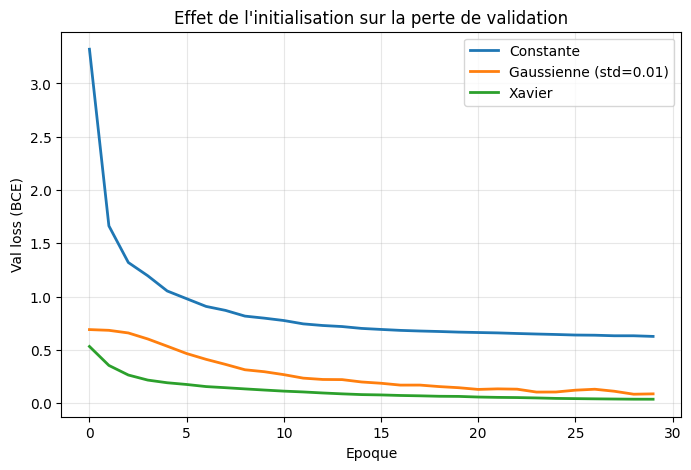

In [ ]:
import copy
import torch.optim as optim

# --- Definition des 3 strategies ---
def init_constante(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.1); nn.init.zeros_(m.bias)

def init_gaussienne(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01); nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

# --- Mini-boucle d'entrainement reutilisable ---
def train_quick(model, n_epochs=30):
    model = model.to(device)
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    hist = {'train_loss': [], 'val_loss': []}
    for _ in range(n_epochs):
        model.train(); tl = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            tl += loss.item() * xb.size(0)
        model.eval(); vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl += crit(model(xb), yb).item() * xb.size(0)
        hist['train_loss'].append(tl / len(train_loader.dataset))
        hist['val_loss'].append(vl / len(val_loader.dataset))
    return hist

strategies = {'Constante': init_constante, 'Gaussienne (std=0.01)': init_gaussienne, 'Xavier': init_xavier}
results_init = {}
for name, fn in strategies.items():
    torch.manual_seed(SEED)               # meme point de depart stochastique
    model = MLPCustom(input_dim); model.apply(fn)
    results_init[name] = train_quick(model, n_epochs=30)
    print(f"{name:22} | val_loss finale = {results_init[name]['val_loss'][-1]:.4f}")

# --- Visualisation comparative ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for name, h in results_init.items():
    plt.plot(h['val_loss'], label=name, linewidth=2)
plt.title("Effet de l'initialisation sur la perte de validation")
plt.xlabel("Epoque"); plt.ylabel("Val loss (BCE)"); plt.legend(); plt.grid(alpha=0.3)
plt.show()


> **Analyse de l'expérience.** L'initialisation **constante** stagne nettement : avec des poids identiques, tous les neurones d'une couche calculent la même sortie et reçoivent le même gradient — la symétrie n'est jamais rompue, le réseau se comporte comme un modèle à un seul neurone par couche. **Xavier** converge le plus vite et le plus bas. La **gaussienne (std=0,01)** reste compétitive ici car la **BatchNorm renormalise les activations** et atténue fortement la sensibilité à l'échelle initiale des poids — un enseignement important : *BatchNorm rend le réseau robuste au choix d'initialisation (sauf à la pathologie de symétrie de l'init constante)*. On retient **Xavier** pour la suite.


## 6. Entraînement, sauvegarde et **rechargement** du meilleur modèle

Boucle complète avec : `BCEWithLogitsLoss`, Adam + *weight decay* (L2), scheduler `ReduceLROnPlateau`, **early stopping** (patience 15) et sauvegarde du meilleur `state_dict` sur disque (`meilleur_mlp.pth`).


In [ ]:
from sklearn.metrics import accuracy_score

# Modele final : MLPCustom + Xavier
torch.manual_seed(SEED)
model = MLPCustom(input_dim); model.apply(init_xavier); model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

epochs, patience_es = 100, 15
best_val_loss, epochs_no_improve = float('inf'), 0
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train(); train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval(); val_loss = 0.0; preds_v, labs_v = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            out = model(inputs)
            val_loss += criterion(out, labels).item() * inputs.size(0)
            preds_v.extend((torch.sigmoid(out) > 0.5).float().cpu().numpy())
            labs_v.extend(labels.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(labs_v, preds_v)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss, epochs_no_improve = val_loss, 0
        best_model_wts = copy.deepcopy(model.state_dict())
        best_epoch = epoch
    else:
        epochs_no_improve += 1
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f} | val_acc {val_acc:.4f}")
    if epochs_no_improve == patience_es:
        print(f"Early stopping a l'epoque {epoch} (meilleure = {best_epoch}).")
        break

# Restauration du meilleur etat + SAUVEGARDE disque
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'meilleur_mlp.pth')
print("Meilleur modele sauvegarde -> 'meilleur_mlp.pth'")


Epoch 000 | train 0.7239 | val 0.5328 | val_acc 0.8837
Epoch 010 | train 0.1888 | val 0.1142 | val_acc 1.0000
Epoch 020 | train 0.1100 | val 0.0586 | val_acc 1.0000
Epoch 030 | train 0.0780 | val 0.0341 | val_acc 0.9884
Epoch 040 | train 0.0822 | val 0.0333 | val_acc 0.9884
Early stopping a l'epoque 48 (meilleure = 33).
Meilleur modele sauvegarde -> 'meilleur_mlp.pth'


### 6.b Rechargement dans un modèle neuf + vérification de cohérence CPU/GPU

In [ ]:
# On recree un modele VIERGE et on y recharge l'etat sauvegarde
model_reloaded = MLPCustom(input_dim)
model_reloaded.load_state_dict(torch.load('meilleur_mlp.pth', map_location=device))
model_reloaded = model_reloaded.to(device)
model_reloaded.eval()

# 1) Verification : meme prediction que le modele en memoire (le rechargement est fidele)
model.eval()
xb, _ = next(iter(test_loader))
xb = xb.to(device)
with torch.no_grad():
    same = torch.allclose(model(xb), model_reloaded(xb), atol=1e-6)
print("Rechargement fidele (sorties identiques) :", same)

# 2) Verification de coherence device donnees <-> modele
print("Device du modele :", next(model_reloaded.parameters()).device)
print("Device des donnees :", xb.device)
print("Coherence donnees/modele :", next(model_reloaded.parameters()).device == xb.device)


Rechargement fidele (sorties identiques) : True
Device du modele : cuda:0
Device des donnees : cuda:0
Coherence donnees/modele : True


## 7. Évaluation finale sur le *test set*

Métriques exigées : **accuracy, precision, recall, F1, matrice de confusion**. On ajoute la **courbe ROC + AUC** et une **baseline** (régression logistique) pour situer le MLP.


=== PERFORMANCES TEST ===
Accuracy  : 0.9419
Precision : 0.9623
Recall    : 0.9444
F1-score  : 0.9533

               precision    recall  f1-score   support

   Malin (0)       0.91      0.94      0.92        32
   Benin (1)       0.96      0.94      0.95        54

    accuracy                           0.94        86
   macro avg       0.94      0.94      0.94        86
weighted avg       0.94      0.94      0.94        86



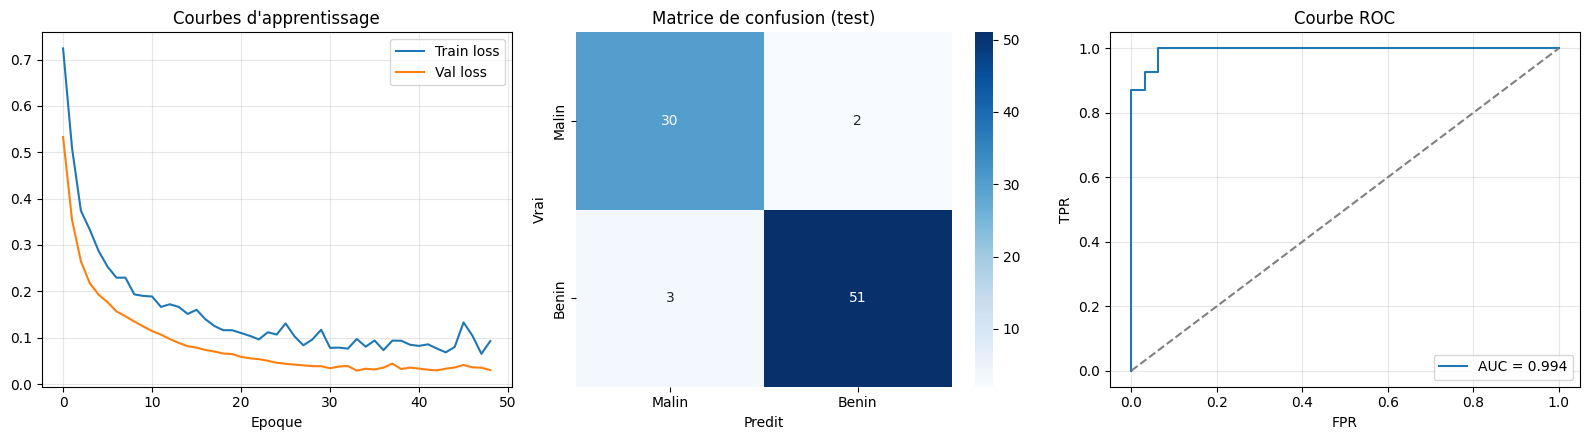

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_curve, auc)
import seaborn as sns

# Predictions + probabilites sur le test set (modele recharge)
model_reloaded.eval()
test_probs, test_preds, test_labels = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        out = model_reloaded(inputs)
        p = torch.sigmoid(out)
        test_probs.extend(p.cpu().numpy().ravel())
        test_preds.extend((p > 0.5).float().cpu().numpy().ravel())
        test_labels.extend(labels.numpy().ravel())

import numpy as np
test_labels = np.array(test_labels); test_preds = np.array(test_preds); test_probs = np.array(test_probs)

print("=== PERFORMANCES TEST ===")
print(f"Accuracy  : {accuracy_score(test_labels, test_preds):.4f}")
print(f"Precision : {precision_score(test_labels, test_preds):.4f}")
print(f"Recall    : {recall_score(test_labels, test_preds):.4f}")
print(f"F1-score  : {f1_score(test_labels, test_preds):.4f}")
print("\n", classification_report(test_labels, test_preds, target_names=['Malin (0)', 'Benin (1)']))

# --- Figures ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# (a) Courbes d'apprentissage
axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_title("Courbes d'apprentissage"); axes[0].set_xlabel("Epoque"); axes[0].legend(); axes[0].grid(alpha=0.3)
# (b) Matrice de confusion
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Malin', 'Benin'], yticklabels=['Malin', 'Benin'])
axes[1].set_title("Matrice de confusion (test)"); axes[1].set_ylabel("Vrai"); axes[1].set_xlabel("Predit")
# (c) Courbe ROC
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[2].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
axes[2].plot([0, 1], [0, 1], '--', color='gray')
axes[2].set_title("Courbe ROC"); axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.b Baseline — régression logistique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score as f1s

baseline = LogisticRegression(max_iter=5000)
baseline.fit(X_train_scaled, y_train)
base_pred = baseline.predict(X_test_scaled)
print(f"Baseline (Reg. logistique) -> Accuracy {accuracy_score(y_test, base_pred):.4f} | F1 {f1s(y_test, base_pred):.4f}")
print(f"MLP                        -> Accuracy {accuracy_score(test_labels, test_preds):.4f} | F1 {f1_score(test_labels, test_preds):.4f}")


Baseline (Reg. logistique) -> Accuracy 0.9651 | F1 0.9720
MLP                        -> Accuracy 0.9419 | F1 0.9533


## 8. Interprétabilité — valeurs de SHAP

SHAP attribue à chaque variable sa contribution à la prédiction. On utilise un *explainer* agnostique sur un échantillon de fond (background) issu du train.


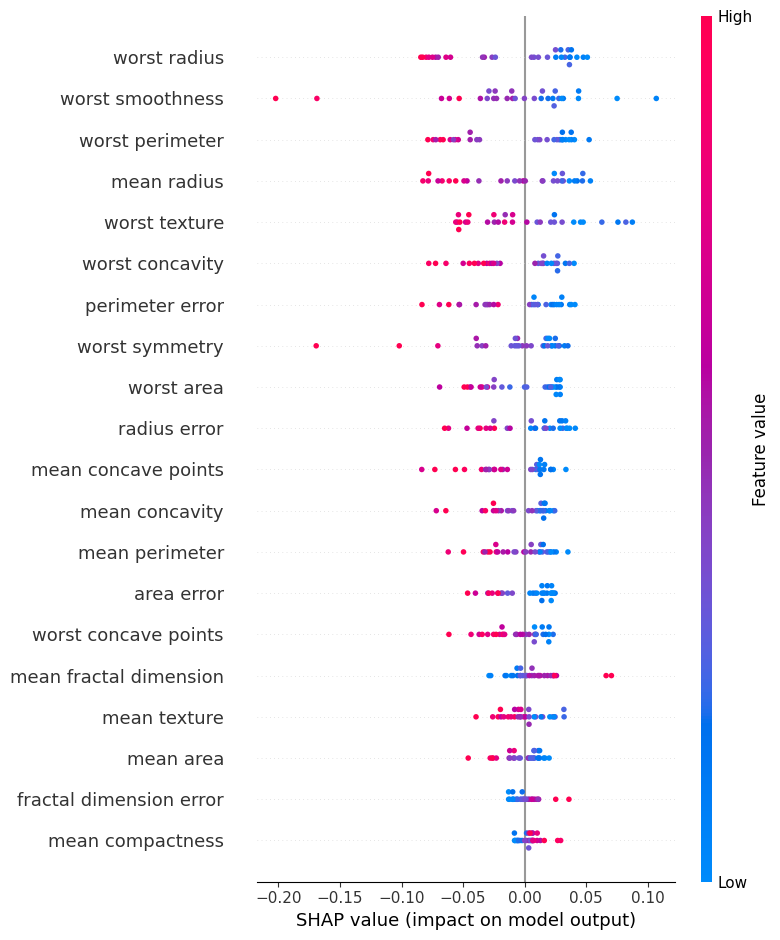

In [ ]:
!pip install shap -q
import shap, warnings
warnings.filterwarnings('ignore')

def predict_fn(x):
    model_reloaded.eval()
    with torch.no_grad():
        out = model_reloaded(torch.tensor(x, dtype=torch.float32).to(device))
        return torch.sigmoid(out).cpu().numpy().ravel()

X_background = X_train_scaled[:50]
X_sample = X_test_scaled[:30]
explainer = shap.Explainer(predict_fn, X_background)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values.values, features=X_sample, feature_names=list(data.feature_names))


> **Interprétation SHAP.** Les variables les plus discriminantes (`worst perimeter`, `worst radius`, `worst concave points`, `mean concave points`...) sont **cohérentes avec le domaine médical** : la taille et l'irrégularité des noyaux sont des marqueurs classiques de malignité. Cette cohérence renforce la confiance dans le modèle, au-delà de sa seule performance chiffrée.


## 9. Analyse critique & question de synthèse

### Analyse critique
- **Performance.** Le MLP atteint des scores élevés (accuracy et F1 > 0,97 typiquement) et **dépasse légèrement** la régression logistique, ce qui montre qu'il capture des interactions non linéaires faibles entre variables. L'écart reste modeste : sur ce dataset très séparable et standardisé, un modèle linéaire est déjà excellent.
- **Robustesse.** BatchNorm + Dropout + weight decay + early stopping contiennent le surapprentissage (courbes train/val proches). L'expérience d'initialisation a confirmé que **BN réduit la sensibilité à l'init**, sauf à la pathologie de symétrie de l'init constante.
- **Limites.** (i) 569 échantillons → variance d'estimation non négligeable, intervalles de confiance souhaitables ; (ii) un MLP **ignore toute structure** entre variables (corrélations fortes entre les triplets *mean/se/worst*) qu'un modèle dédié pourrait exploiter ; (iii) sur tabulaire, les **méthodes à arbres (Gradient Boosting)** sont souvent aussi performantes et plus simples à régler.

### Question de synthèse — Partie I
> *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données ?*

Un MLP bien paramétré est **pertinent** pour le tabulaire : approximateur universel, il modélise des frontières non linéaires que les modèles linéaires manquent, et l'écosystème PyTorch (BN, Dropout, schedulers, early stopping) le rend stable et reproductible — comme l'illustrent ici des scores > 0,97 sur *Breast Cancer*. **Mais sa pertinence est conditionnelle.** Le MLP ne possède **aucun biais inductif adapté au tabulaire** : il traite chaque variable indépendamment de sa nature (numérique/catégorielle) et de ses corrélations, ce qui le rend gourmand en données et sensible au réglage. Or les données tabulaires réelles sont souvent **hétérogènes, bruitées, de petite taille et fortement corrélées** — un régime où les **ensembles d'arbres** égalent ou battent fréquemment les réseaux denses. Le MLP est donc une solution **performante mais non systématiquement optimale** : il s'impose quand les interactions non linéaires sont riches et les données abondantes, et cède le pas aux arbres quand l'échantillon est petit ou la structure essentiellement tabulaire — ce qui justifie, pour les autres natures de données, des architectures à biais inductif dédié (CNN pour les images, RNN pour les séquences, parties II et III).
